# Titel der Analyse

Untertitel

Dein Name

## LLM-Setup

Konfiguriere deinen AI-Helfer einmalig vor Beginn deiner Analyse. Führe die Code-Zellen in diesem Abschnitt bei jeder Verwendung dieses Notebooks einmalig aus.

Wenn etwas schief geht, kannst du die folgenden Zellen nochmals ausführen, um in den Startzustand zurückzukehren.

### Ollama Rechenwerk

In [2]:
import ollama

Entscheide dich, ob du **entweder** Ollama-Cloud **oder** einen lokalen Ollama-Server verwenden willst. Wo läuft dein Modell?

#### Cloud

Dein Computer ist zu langsam oder hat nicht genügend RAM (16GB+)? Dann verwende Ollama Cloud. Informationen zu Ollama-Cloud findest du unter [docs.ollama.com/cloud](https://docs.ollama.com/cloud#cloud-models)

In [3]:
OLLAMA_API_KEY="9d3aa5f6cdea4c549ecb32a9ed7e0446.8in8Dd5NcFYhzLObRIb_uz0g"

Deinen eigenen privaten API-Schlüssel erstellst du nach dem Login unter [ollama.com/settings/keys](https://ollama.com/settings/keys).

In [4]:
client = ollama.Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer ' + OLLAMA_API_KEY}
)

### Hilfsfunktionen

Für die einfachere Handhabung nutzen wir die zwei selbstgeschriebenen Funktionen `ask()` und `chat()`. Unser Code im Notebook ist dann übersichtlicher.

In [5]:
from IPython.display import display, Markdown
import pandas as pd
import json
import os

def load_conversation_log(filename = "llm_conversation_log.json"):
    """Liest ein .json-Datei, welche eine Aufzeichnung einer Unterhaltung enthält, ein."""
    global messages
    if os.path.exists(filename):
        with open(filename, 'r') as file:
            content = json.loads(file.read())
        if content[0].get("role") == "system":
            print("Loading", filename)
            messages = content

def save_conversation_log(filename = "llm_conversation_log.json"):
    """Schreibt die aktuelle Aufzeichnung der Unterhaltung in eine .json-Datei."""
    with open( filename , "w" ) as file:
        json.dump( messages , file )
    
def ask(prompt):
    """Einfacher Chat-Bot mit global spezifiziertem Client, Modell - ohne Historie"""
    global client
    global model_name
    response = client.generate(model=model_name, prompt=prompt)
    display(Markdown(response.response))

def remove_message(msg_list, n=1):
    """Entfernt die ältesten n einträge aus einer Unterhaltung"""
    #print("Cleanup - removing {} oldest message from chat history".format(n))
    return msg_list[0:1] + msg_list[(n+1):]
    
def chat(prompt):
    """Einfacher Chat-Bot mit global spezifiziertem Client, Modell und Historie"""
    global client
    global model_name
    global messages
    global max_chat_history
    
    messages.append({"role": "user", "content": prompt})

    if max_chat_history != 0:
        message_count = len(messages) - 1
        
        # remove exess chat history, if we have fixed size max_chat_history
        excess_messages = message_count - max_chat_history
        if max_chat_history > 0 and excess_messages > 0:
            messages = remove_message(messages, excess_messages)

        # if context window is (still) to long, we always remove old chat entries
        for _ in range(message_count + 1):
            try:
                response = client.chat(model=model_name, messages=messages)
            except ollama.ResponseError as e:
                if len(messages) > 1:
                    messages = remove_message(messages, 1)
                    continue
                raise
            except Exception as e:
                raise
    else:
        # no context lenght limit - expect your client to die eventually
        response = client.chat(model=model_name, messages=messages)
        
    messages.append({"role": "assistant", "content": response.message.content})
    save_conversation_log()
    display(Markdown(response.message.content))

def show_models_from_(output):
    """Gibt die Modelle von client.list() als Pandas Dataframe zurück"""
    df = pd.DataFrame([
        {
            "Model": entry.get("model", ""),
            "Size [GB]": round(int(entry.get("size", 0)) / 1024**3, 1)
        }
        for entry in output.get("models", [])
    ])

    if not df.empty:
        df = df.sort_values(by="Model", key=lambda s: s.str.lower())

    df = df.reset_index(drop=True)
    return df

Wichtig: Die globalen Variablen `model_name` und `messages` und `max_chat_history` müssen vor der Verwendung definiert werden. Dazu alle Code-Zellen bis **Modelltest** einmalig nacheinander ausführen. 

### Chat-History


Die Funktion `chat()` verwendet auch die bisherige Konversation als Eingabe - so "erinnert" sich ein Modell, was alles schon besprochen wurde. Die maximal Länge der Eingabe ist von Modell zu Modell verschieden aber immer begrenzt - genau wie die maximale Länge der Ausgabe eines Modells. Mit der globalen Variable `max_chat_history` kannst du einstellen, wie viele der vorhergehenden Fragen und Antworten im `chat()` verwendet werden.

|Wert|Bedeutung|
|--|--|
|-1|Model Limit - das heisst, dass dein Chat-Client soviel History wie möglich verwendet. Wenn du einen langsamen Computer hast, ist diese Einstellung keine gute Idee. Wenn du Ollama-Cloud verwendest oder einen sehr schnellen Computer hast, dann ist ggf. -1 eine gute Wahl|
|0|ohne Limit - das heisst, dass dein Chat-Client irgendwann abstützen wird - nur zu empfehlen zum Testen des "maximum context window" - also der maximalen Eingabelänge eines Modells.|
|3,4,5,...|festes Limit - Wenn du bspw. 3 wählst, dann "erinnert" sich dein Chatbot maximal an die drei vorhergehenden Fragen und Antworten. Wenn Ollama lokal läuft und/oder dein Computer langsam ist, solltest du eine kleine Zahl wie bspw. `5` wählen. Versuch macht kluch!|

In [6]:
max_chat_history = 7

### Modellauswahl

Modellübersicht: https://ollama.com/search

Welche Modelle gibt es auf deinem Ollama-Server oder bei Ollama-Cloud?

In [7]:
show_models_from_(client.list())

,Model,Size [GB]
0,cogito-2.1:671b,641.3
1,deepseek-v3.1:671b,641.3
2,deepseek-v3.2,641.3
3,devstral-2:123b,119.4
4,devstral-small-2:24b,48.1
5,gemini-3-flash-preview,0.0
6,gemma3:12b,22.4
7,gemma3:27b,51.2
8,gemma3:4b,8.0
9,glm-4.6,648.3


Wenn Ollama lokal läuft, achte auf die Grösse des Modells (in GB) im Verhältnis zum verfügbaren Arbeitsspeicher. Grösser heisst i.d.R. auch langsamer - aber nicht zwangsläufig auch immer besser.

Mit welchem Modell willst du arbeiten?

In [8]:
model_name = 'gemma3:4b' # Starte mit diesem, wenn du Ollama-Cloud verwendest

#model_name = 'gemma3:270m' # Starte mit diesem, wenn du Ollama lokal laufen lässt
#model_name = 'gemma3:1b'

# weitere Beispiele
#model_name = 'deepseek-r1:1.5b'
#model_name = 'codegemma:2b'

Wenn du **nicht** Ollama-Cloud verwendest, installierst du neue Modelle auf dem Ollama-Server, mit dem du gerade verbunden bist, so: (entferne in dem Fall die #)

In [9]:
#client.pull(model_name)

oder so:

In [10]:
#%%bash
#ollama pull gemma3:270m

### Priming

Entweder starten wir ganz frisch **ODER** wir setzen eine Unterhaltung fort.

#### Frischer Start

Wir speichern die gesamte Unterhaltung in der globalen Variablen `messages`. Am Anfang können wir das Modell noch `primen`.

In [11]:
priming = """
You are the best Python coder in the world.
You know Pandas and all of Pandas functionality inside out.
You use directly Pandas data frames for plotting and do NOT use matplotlib or seaborn explicitly.
You code like a student in 10th grade and prefer simple solutions.
You give short and informative answers and in-detail code explanations only on request.
"""

In [12]:
messages = [
    {"role": "system", "content": priming}
]

#### Unterhaltung fortsetzen

Falls vorhanden, wird die Datei `llm_conversation_log.json` in die globale Variable `messages` eingelesen.

In [13]:
load_conversation_log()

Loading llm_conversation_log.json


### Modelltest

Wir testen, ob alle Variablen und Funktionen vorhanden sind - falls nicht, hast du vermutlich vergessen, eine der vorhergehenden Code-Zellen auszuführen.

In [14]:
MUST_HAVE_OBJECTS = ('ollama', 'client', 'chat', 'ask', 'max_chat_history', 'model_name', 'priming', 'messages')

llm_setup_errors = 0
for one_object in MUST_HAVE_OBJECTS:
    if one_object not in locals():
        llm_setup_errors += 1
        print("ERROR:", one_object, "nicht gefunden - bitte die zugehörige, vorhergehende Code-Zelle einmalig ausführen!")
        
assert llm_setup_errors == 0

Ausserdem testen wir, ob du eine Modell ausgewählt hast, was auch auf dem Ollama-Server vorhanden ist.

In [15]:
assert model_name in list(show_models_from_(client.list())["Model"])

Okay, lass uns das aufschlüsseln! Hier ist der Prozess mit Beispielen:

    Daten laden: df = pd.read_csv('deine_datei.csv')
    Daten verstehen: df.head(), df.info(), df.describe() (wie vorher)
    Daten vorbereiten: Bereinigen (Fehlerhafte Werte, fehlende Daten)
    Analyse: Verwende .groupby(), .pivot_table(), .corr() wie du kennst.
    Visualisierung: Verwende df.plot() für einfache Plots.

Beispiele für Visualisierungen:

    Barplot: df['Spalte'].value_counts().plot(kind='bar') (zeigt die Häufigkeit von Werten in einer Spalte)
    Lineplot: df.plot(x='Datum', y='Wert', kind='line')
    Scatterplot: df.plot(x='Spalte1', y='Spalte2', kind='scatter')
    Boxplot: df.boxplot(column='Spalte')
    Violinplot: df.plot(kind='violin', column='Spalte')
    Heatmap (Korrelation): df.corr().plot(kind='heatmap')

Wichtig: kind ist der Parameter, der bestimmt, welchen Plot du erzeugst.

Welche Art von Daten hast du und was möchtest du visualisieren? Dann kann ich dir spezifischere Hinweise geben.

## Forschungsfragen

1. ...
2. ...
3. ...

ACHTUNG: WENN DIE ARBEIT AM NOTEBOOK NACH EINER PAUSE WIEDER AUFGENOMMEN WIRD, MÜSSEN DIE **CHAT-ZELLEN** NATÜRLICH **NICHT** NOCHMAL AUSGEFÜHRT WERDEN!

Es genügt, alle Zellen, welche für das LLM zuständig sind, auszuführen und dann direkt zum Abschnitt "Hier beim nächsten Mal starten" zu wechseln.

## Daten einlesen

In [16]:
chat("""
Wie liest man eine komma-separierte Datei in Python mit Pandas ein, 
wenn das Trennzeichen ein Semikolon ist? Was ändert sich, wenn das Trennzeichen ein Komma ist?
""")

```python
import pandas as pd

# Mit Semikolon als Trennzeichen
df = pd.read_csv('datei.csv', sep=';')

# Mit Komma als Trennzeichen
df = pd.read_csv('datei.csv', sep=',')

print(df.head())
```

**Erklärung:**

*   **`sep=';'`**:  Das `sep`-Argument in `pd.read_csv()` gibt das Trennzeichen an.  Hier verwenden wir Semikolon.
*   **`sep=','`**: Wenn das Trennzeichen ein Komma ist, verwenden wir `sep=','`.

**Was sich ändert:**

Wenn sich das Trennzeichen ändert, liest Pandas die Datei korrekt ein, indem es die Werte anhand des neuen Trennzeichens aufteilt.  Wenn das Trennzeichen nicht angegeben ist, geht Pandas davon aus, dass es ein Komma ist.  Wenn die Datei andere Trennzeichen verwendet, muss `sep` entsprechend angepasst werden.  Wenn das Trennzeichen nicht erkannt wird, wird eine Fehlermeldung ausgegeben.

In [49]:
import pandas as pd

In [50]:
df = pd.read_csv('KSZO-solar-data.csv', sep=",")
df

,time_utc,time_local,consumption,production,battery_charging,battery_discharging,battery_currentPower,battery_activeDevice,smart_meter_currentPower,smart_meter_activeDevice,inverter_WR_MS1_currentPower,inverter_WR_MS1_activeDevice,inverter_SolarEdge_SE_currentPower,inverter_SolarEdge_SE_activeDevice,inverter_WR_MS2_currentPower,inverter_WR_MS2_activeDevice
0,2023-12-28T15:45:00,2023-12-28T16:45:00,41640,0,0,0,52.00,1.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0
1,2023-12-28T16:00:00,2023-12-28T17:00:00,42226,0,0,0,52.00,1.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0
2,2023-12-28T16:15:00,2023-12-28T17:15:00,42226,0,0,0,52.00,1.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0
3,2023-12-28T16:30:00,2023-12-28T17:30:00,42226,0,0,0,52.00,1.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0
4,2023-12-28T16:45:00,2023-12-28T17:45:00,42226,0,0,0,52.00,1.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77163,2026-03-11T11:30:00,2026-03-11T12:30:00,66987,90984,0,0,-10019.00,1.0,-23996.33,1.0,30900.67,1.0,30900.67,1.0,29182.33,1.0
77164,2026-03-11T11:45:00,2026-03-11T12:45:00,62299,87617,0,0,-10026.00,1.0,-25317.33,1.0,29737.33,1.0,29737.33,1.0,28143.00,1.0
77165,2026-03-11T12:00:00,2026-03-11T13:00:00,60324,136516,0,0,-10012.33,1.0,-76339.00,1.0,46576.00,1.0,46576.00,1.0,43364.33,1.0
77166,2026-03-11T12:15:00,2026-03-11T13:15:00,65548,106002,0,0,-10008.00,1.0,-41052.00,1.0,36034.67,1.0,36034.67,1.0,33933.00,1.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77168 entries, 0 to 77167
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   time_utc                            77168 non-null  object 
 1   time_local                          77168 non-null  object 
 2   consumption                         77168 non-null  int64  
 3   production                          77168 non-null  int64  
 4   battery_charging                    77168 non-null  int64  
 5   battery_discharging                 77168 non-null  int64  
 6   battery_currentPower                75459 non-null  float64
 7   battery_activeDevice                75459 non-null  float64
 8   smart_meter_currentPower            75459 non-null  float64
 9   smart_meter_activeDevice            75459 non-null  float64
 10  inverter_WR_MS1_currentPower        75459 non-null  float64
 11  inverter_WR_MS1_activeDevice        75459

In [19]:
df.describe()

,consumption,production,battery_charging,battery_discharging,battery_currentPower,battery_activeDevice,smart_meter_currentPower,smart_meter_activeDevice,inverter_WR_MS1_currentPower,inverter_WR_MS1_activeDevice,inverter_SolarEdge_SE_currentPower,inverter_SolarEdge_SE_activeDevice,inverter_WR_MS2_currentPower,inverter_WR_MS2_activeDevice
count,77168.000000,77168.000000,77168.0,77168.0,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000
mean,26225.697323,29743.150853,0.0,0.0,397.163727,0.773453,-2097.168527,0.783790,10526.983801,0.445951,9775.468057,0.395579,10116.253182,0.446203
std,21170.904711,57284.240071,0.0,0.0,3277.503354,0.418600,42069.929279,0.411662,19685.964894,0.497073,19514.176152,0.488978,19206.374419,0.497101
min,0.000000,0.000000,0.0,0.0,-10057.670000,0.000000,-245751.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9524.000000,0.000000,0.0,0.0,-52.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16702.000000,0.000000,0.0,0.0,-52.000000,1.000000,8467.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42226.000000,28662.250000,0.0,0.0,0.000000,1.000000,10705.165000,1.000000,10810.625000,1.000000,8179.395000,1.000000,9936.325000,1.000000
max,109785.000000,268980.000000,0.0,0.0,19793.000000,1.000000,84918.810000,1.000000,89854.560000,1.000000,89972.220000,1.000000,89283.110000,1.000000


## Daten vorverarbeiten

Nur die Spalten behalten, die wir derzeit benötigen.

In [30]:
chat("""
Remove all collumns from data frame, except time_local, production and consumption

#   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   time_utc                            77168 non-null  object 
 1   time_local                          77168 non-null  object 
 2   consumption                         77168 non-null  int64  
 3   production                          77168 non-null  int64  
 4   battery_charging                    77168 non-null  int64  
 5   battery_discharging                 77168 non-null  int64 
""")

```python
df = df[['time_local', 'production', 'consumption']]
```

This creates a new DataFrame containing only the specified columns.

In [51]:
df = df.loc[:,['time_local', 'consumption', 'production']]

Zum Rechnen müssen wir die Stings in DateTime-Objekte umwandeln.

In [29]:
chat("""
Convert this into datetime

df['time_local']

time_local
0 	2023-12-28T15:45:00
1 	2023-12-28T16:00:00
2 	2023-12-28T16:15:00
3 	2023-12-28T16:30:00
4 	2023-12-28T16:45:00
""")

```python
df['time_local'] = pd.to_datetime(df['time_local'])
```

This line uses the `pd.to_datetime()` function to convert the 'time_local' column to datetime objects.  Pandas automatically infers the format from the string values.

In [52]:
df['time_local'] = pd.to_datetime(df['time_local'])

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77168 entries, 0 to 77167
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_local   77168 non-null  datetime64[ns]
 1   consumption  77168 non-null  int64         
 2   production   77168 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.8 MB


Wir wollen später aggregieren, z.B. nach Jahr und Monat.

In [31]:
chat("""
Berechne aus df['time_local'] folgende neue Spalten

- Kalenderwoche
- Stunde
- Wochentag
- Monat
- Quartal
- Jahr
""")

```python
import pandas as pd

# Ensure 'time_local' is datetime
df['time_local'] = pd.to_datetime(df['time_local'])

# Calendar week
df['calendar_week'] = df['time_local'].dt.isocalendar().week

# Hour
df['hour'] = df['time_local'].dt.hour

# Weekday
df['weekday'] = df['time_local'].dt.day_name()

# Month
df['month'] = df['time_local'].dt.month

# Quarter
df['quarter'] = df['time_local'].dt.quarter

# Year
df['year'] = df['time_local'].dt.year

print(df.head())
```

This code first converts the 'time\_local' column to datetime objects. Then, it uses the `.dt` accessor to extract the desired features: `isocalendar().week` for the calendar week, `hour` for the hour, `day_name()` for the weekday, `month` for the month, `quarter` for the quarter, and `year` for the year.  Finally, it adds these new columns to the DataFrame.


In [54]:
df.loc[:,'hour']  = df['time_local'].dt.hour
df.loc[:,'month'] = df['time_local'].dt.month
df.loc[:,'quarter'] = df['time_local'].dt.quarter
df.loc[:,'year'] = df['time_local'].dt.year
df.loc[:,'day_of_week'] = df['time_local'].dt.dayofweek
df.loc[:,'day_name'] = df['time_local'].dt.day_name()

Damit wir mit `sum()` die Viertelstundenwerte der Leistung `P` aggregieren können und `Wh` als Einheit erhalten, müssen wir die Leistung jeweils durch 4 dividieren. Warum?

$$W = P \cdot t$$

d.h. um die elektrische Arbeit (`W`) in der Einheit `Wh` aus Leistungsmessungen über $t = \frac{1}{4}h$ zu berechnen, müssen wir die Leistung $P$, die für 15min geleistet wird, mit $\frac{1}{4}$ multiplizieren bzw. durch $4$ dividieren, um auf `Wh` als Einheit zu kommen.

In [55]:
df.loc[:,'production_Wh'] = df['production'] / 4
df.loc[:,'consumption_Wh'] = df['consumption'] / 4

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77168 entries, 0 to 77167
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   time_local      77168 non-null  datetime64[ns]
 1   consumption     77168 non-null  int64         
 2   production      77168 non-null  int64         
 3   hour            77168 non-null  int32         
 4   month           77168 non-null  int32         
 5   quarter         77168 non-null  int32         
 6   year            77168 non-null  int32         
 7   day_of_week     77168 non-null  int32         
 8   day_name        77168 non-null  object        
 9   production_Wh   77168 non-null  float64       
 10  consumption_Wh  77168 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(5), int64(2), object(1)
memory usage: 5.0+ MB


In [26]:
df

,time_local,consumption,production,hour,month,quarter,year,day_of_week,day_name,production_Wh,consumption_Wh
0,2023-12-28 16:45:00,41640,0,16,12,4,2023,3,Thursday,0.00,10410.00
1,2023-12-28 17:00:00,42226,0,17,12,4,2023,3,Thursday,0.00,10556.50
2,2023-12-28 17:15:00,42226,0,17,12,4,2023,3,Thursday,0.00,10556.50
3,2023-12-28 17:30:00,42226,0,17,12,4,2023,3,Thursday,0.00,10556.50
4,2023-12-28 17:45:00,42226,0,17,12,4,2023,3,Thursday,0.00,10556.50
...,...,...,...,...,...,...,...,...,...,...,...
77163,2026-03-11 12:30:00,66987,90984,12,3,1,2026,2,Wednesday,22746.00,16746.75
77164,2026-03-11 12:45:00,62299,87617,12,3,1,2026,2,Wednesday,21904.25,15574.75
77165,2026-03-11 13:00:00,60324,136516,13,3,1,2026,2,Wednesday,34129.00,15081.00
77166,2026-03-11 13:15:00,65548,106002,13,3,1,2026,2,Wednesday,26500.50,16387.00


## Daten analysieren

In [37]:
chat("""
Create a plot of production_Wh and consumption_Wh over time_local using df directly.

#   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   time_local      77168 non-null  datetime64[ns]
 1   consumption     77168 non-null  int64         
 2   production      77168 non-null  int64         
 3   hour            77168 non-null  int32         
 4   month           77168 non-null  int32         
 5   quarter         77168 non-null  int32         
 6   year            77168 non-null  int32         
 7   day_of_week     77168 non-null  int32         
 8   day_name        77168 non-null  object        
 9   production_Wh   77168 non-null  float64       
 10  consumption_Wh  77168 non-null  float64       
 """)

```python
import pandas as pd
import matplotlib.pyplot as plt

df.plot(x='time_local', y=['production_Wh', 'consumption_Wh'], figsize=(12, 6))
plt.xlabel('Time')
plt.ylabel('Wh')
plt.title('Production and Consumption Over Time')
plt.grid(True)
plt.show()
```

This code directly plots the 'time\_local' column against the 'production\_Wh' and 'consumption\_Wh' columns using `df.plot()`. This eliminates the need to create separate data series and streamlines the plotting process.  It also includes labels for the axes and a title.

<Axes: xlabel='time_local'>

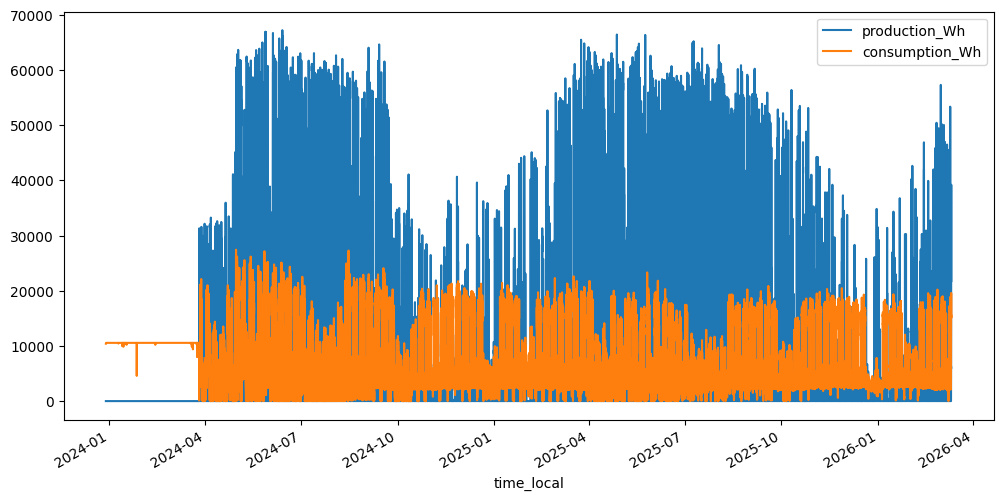

In [56]:
df.plot(x='time_local', y=['production_Wh', 'consumption_Wh'], figsize=(12, 6))

Die Daten vor April 2024 sehen falsch aus. Wir entfernen diese.

In [41]:
chat("""
Remove all rows for time_local before 2024-04-01
 """)

```python
df = df[df['time_local'] >= '2024-04-01']
```

This code filters the DataFrame `df` to keep only the rows where the value in the 'time\_local' column is greater than or equal to '2024-04-01'.  The filtered DataFrame is then assigned back to the variable `df`, effectively removing rows before that date.

In [57]:
min_cut_off_date = pd.to_datetime('2024-04-01')

print(min_cut_off_date)

df = df[df['time_local'] >= min_cut_off_date]

2024-04-01 00:00:00


<Axes: xlabel='time_local'>

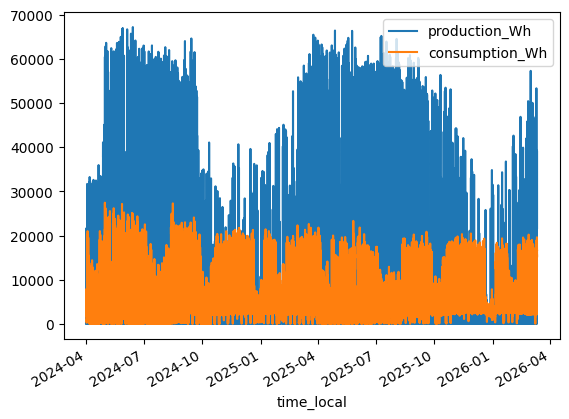

In [58]:
df.plot(x='time_local', y=['production_Wh', 'consumption_Wh'])

In [47]:
chat("""
Wie berechne ich aus dem Dataframe die Summen, gruppiert nach den Spalten Jahr und dann nach Monat?
von production_Wh mit groupby() 
""")

```python
monthly_production = df.groupby(['year', 'month'])['production'].sum()
print(monthly_production)
```

This code groups the DataFrame by both 'year' and 'month' columns and then calculates the sum of 'production' for each unique combination of year and month. The result is stored in `monthly_production`.

In [59]:
df.groupby(['year','month'])[['consumption_Wh', 'production_Wh']].sum()

consumption_Wh  production_Wh
year month                               
2024 4         17001115.25    18696950.25
     5         23869651.00    36678932.00
     6         20487734.25    36968003.25
     7         13592573.50    43554884.50
     8         20362286.50    43795359.00
     9         19749486.50    24842958.50
     10        14443821.50     9232654.25
     11        21130599.50     5833926.00
     12        17689020.00     5791241.75
2025 1         18538888.75     9641220.75
     2         16381991.50    10358151.75
     3         19243535.00    29544380.00
     4         15332858.00    40811463.00
     5         17563444.00    39713876.25
     6         16881286.25    47718669.50
     7         11799127.50    40551764.75
     8         17036880.50    41494156.50
     9         18265016.50    24413384.25
     10        16585674.25    16599051.25
     11        19959506.75    10194019.00
     12        16198193.50     4745056.75
2026 1         17274990.75     6146303.50
     2         16262612.25    12778370.25
     3          6949059.75    11172374.00

Wir wollen kWh als Einheit haben - also alles nochmal durch 100 dividieren.

In [31]:
df.groupby(['year','month'])[['consumption_Wh', 'production_Wh']].sum()/1000

consumption_Wh  production_Wh
year month                               
2024 4         17001.11525    18696.95025
     5         23869.65100    36678.93200
     6         20487.73425    36968.00325
     7         13592.57350    43554.88450
     8         20362.28650    43795.35900
     9         19749.48650    24842.95850
     10        14443.82150     9232.65425
     11        21130.59950     5833.92600
     12        17689.02000     5791.24175
2025 1         18538.88875     9641.22075
     2         16381.99150    10358.15175
     3         19243.53500    29544.38000
     4         15332.85800    40811.46300
     5         17563.44400    39713.87625
     6         16881.28625    47718.66950
     7         11799.12750    40551.76475
     8         17036.88050    41494.15650
     9         18265.01650    24413.38425
     10        16585.67425    16599.05125
     11        19959.50675    10194.01900
     12        16198.19350     4745.05675
2026 1         17274.99075     6146.30350
     2         16262.61225    12778.37025
     3          6949.05975    11172.37400

Nur mal das Jahr 2025

In [47]:
(df[df['year'] == 2025]
 .groupby(['year','month'])[['consumption_Wh', 'production_Wh']]
 .sum()/1000).round()

consumption_Wh  production_Wh
year month                               
2025 1             18539.0         9641.0
     2             16382.0        10358.0
     3             19244.0        29544.0
     4             15333.0        40811.0
     5             17563.0        39714.0
     6             16881.0        47719.0
     7             11799.0        40552.0
     8             17037.0        41494.0
     9             18265.0        24413.0
     10            16586.0        16599.0
     11            19960.0        10194.0
     12            16198.0         4745.0

Für `production` scheint das zu stimmen für Juni 2025 - `47'719` kWh - vgl. mit dem Screenhot aus OneNote.

Wir raten mal, dass man einen aggregierten DataFrame auch direkt plotten kann?

<Axes: xlabel='year,month'>

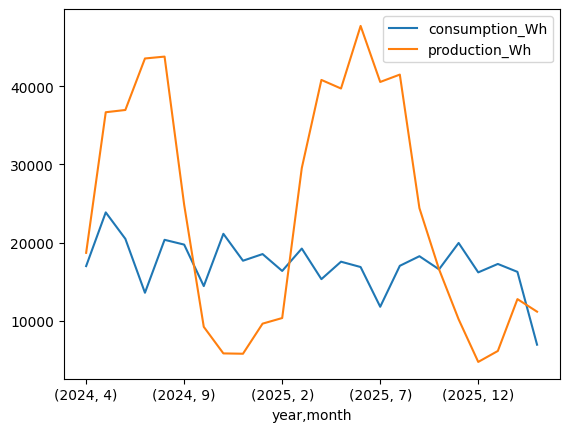

In [32]:
(df.groupby(['year','month'])[['consumption_Wh', 'production_Wh']].sum()/1000).plot()

Das Schweizer Sackmesser der Datenanalyse ist die [Pivot-Tabelle](de.wikipedia.org/wiki/Pivot-Tabelle). Versuchen wir es mal damit.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html

In [52]:
chat("""
Nutze nicht groupby() sondern pivot_table()
""")

```python
monthly_production = df.pivot_table(index='year', columns='month', values='production', aggfunc='sum')
print(monthly_production)
```

This code uses `pivot_table()` to reshape the DataFrame.  It sets 'year' as the index, 'month' as the columns, 'production' as the values, and uses 'sum' as the aggregation function. The result `monthly_production` is a table with years as rows, months as columns, and the sum of production for each year-month combination.

Wir wollen `year` und `month` als Zeilen

In [33]:
df.pivot_table(index=['year', 'month'], 
               values=['production_Wh'], 
               aggfunc='sum')

production_Wh
year month               
2024 4        18696950.25
     5        36678932.00
     6        36968003.25
     7        43554884.50
     8        43795359.00
     9        24842958.50
     10        9232654.25
     11        5833926.00
     12        5791241.75
2025 1         9641220.75
     2        10358151.75
     3        29544380.00
     4        40811463.00
     5        39713876.25
     6        47718669.50
     7        40551764.75
     8        41494156.50
     9        24413384.25
     10       16599051.25
     11       10194019.00
     12        4745056.75
2026 1         6146303.50
     2        12778370.25
     3        11172374.00

Wir können überall Listen anstelle von Einzelwerten angeben.

Als auf die Zeilen bspw. `['year', 'month']` und gleichzeitig die Berechnungen `['count', 'sum', 'mean']` ausführen.

- count : zählt Anzahl der Werte in der Gruppe
- sum : summiert alle Werte in der Gruppe
- mean : berechnet den Mittelwert aller Gruppenwerte

Pivot hat die Möglichkeit, auf Spalten und Columns zu pivotisieren

In [39]:
df.pivot_table(index=['year', 'month'], 
               values=['production_Wh', 'consumption_Wh'], 
               aggfunc=['count', 'sum', 'mean'])

count                          sum                \
           consumption_Wh production_Wh consumption_Wh production_Wh   
year month                                                             
2024 4               2880          2880    17001115.25   18696950.25   
     5               2971          2971    23869651.00   36678932.00   
     6               2880          2880    20487734.25   36968003.25   
     7               2976          2976    13592573.50   43554884.50   
     8               2976          2976    20362286.50   43795359.00   
     9               2880          2880    19749486.50   24842958.50   
     10              2980          2980    14443821.50    9232654.25   
     11              2880          2880    21130599.50    5833926.00   
     12              2976          2976    17689020.00    5791241.75   
2025 1               2977          2977    18538888.75    9641220.75   
     2               2688          2688    16381991.50   10358151.75   
     3               2972          2972    19243535.00   29544380.00   
     4               2880          2880    15332858.00   40811463.00   
     5               2976          2976    17563444.00   39713876.25   
     6               2880          2880    16881286.25   47718669.50   
     7               2976          2976    11799127.50   40551764.75   
     8               2976          2976    17036880.50   41494156.50   
     9               2880          2880    18265016.50   24413384.25   
     10              2980          2980    16585674.25   16599051.25   
     11              2880          2880    19959506.75   10194019.00   
     12              2976          2976    16198193.50    4745056.75   
2026 1               2976          2976    17274990.75    6146303.50   
     2               2688          2688    16262612.25   12778370.25   
     3               1015          1015     6949059.75   11172374.00   

                     mean                
           consumption_Wh production_Wh  
year month                               
2024 4        5903.165017   6491.996615  
     5        8034.214406  12345.651969  
     6        7113.796615  12836.112240  
     7        4567.397009  14635.377856  
     8        6842.166163  14716.182460  
     9        6857.460590   8626.027257  
     10       4846.919966   3098.206124  
     11       7337.013715   2025.668750  
     12       5943.891129   1945.981771  
2025 1        6227.372775   3238.569281  
     2        6094.490885   3853.479074  
     3        6474.944482   9940.908479  
     4        5323.909028  14170.646875  
     5        5901.694892  13344.716482  
     6        5861.557726  16568.982465  
     7        3964.760585  13626.265037  
     8        5724.758233  13942.928931  
     9        6342.019618   8476.869531  
     10       5565.662500   5570.151426  
     11       6930.384288   3539.589931  
     12       5442.941364   1594.441112  
2026 1        5804.768397   2065.290155  
     2        6050.078962   4753.857980  
     3        6846.364286  11007.265025

## Zwischenstand speichern

Damit wir nicht bei jedem Start alle Zellen dieses Notebooks wieder und wieder ausführen müssen, speichern wir uns den aktuellen Zustand unseres DataFrames.

In [60]:
df.to_csv("zwischenstand.csv", index=False)

## Hier beim nächsten Mal starten

In [ ]:
import pandas as pd

df = pd.read_csv('zwischenstand.csv', sep=",")

df['time_local'] = pd.to_datetime(df['time_local'])

In [ ]:
df.info()

## Daten visualisieren